# Regresión Logística — Sistemas Basados en Conocimiento

**Autor:** Víctor Vargas Miranda  
**Dataset:** [Digits Dataset — Scikit-Learn](https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html)  
**Librería principal:** [scikit-learn](https://scikit-learn.org/stable/install)

---

## 1. ¿Qué problema resuelve la Regresión Logística?

La **Regresión Logística** es un algoritmo de aprendizaje supervisado utilizado para resolver problemas de **clasificación**. A pesar de llevar la palabra "regresión" en su nombre, su objetivo no es predecir un valor continuo, sino estimar la probabilidad de que una observación pertenezca a una clase determinada.

### Formulación matemática

El modelo aplica la función **sigmoide** (también llamada función logística) a una combinación lineal de las características de entrada:

$$P(y=1 \mid X) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

donde:
- $\mathbf{w}$ son los pesos (coeficientes) del modelo
- $\mathbf{x}$ es el vector de características de una observación
- $b$ es el término de sesgo (bias)
- $\sigma(\cdot)$ es la función sigmoide que mapea cualquier valor real al intervalo $[0, 1]$

La predicción final se obtiene comparando esta probabilidad contra un umbral (generalmente 0.5):

$$\hat{y} = \begin{cases} 1 & \text{si } P(y=1 \mid X) \geq 0.5 \\ 0 & \text{en caso contrario} \end{cases}$$

Para el caso **multiclase** (como el reconocimiento de dígitos), se utiliza la generalización llamada **Regresión Logística Multinomial** (o Softmax), que extiende el modelo a $K$ clases simultáneamente.

## 2. Supuestos Fundamentales del Modelo

La Regresión Logística parte de los siguientes supuestos:

1. **Variable dependiente categórica:** La variable a predecir debe ser discreta (binaria o multiclase), no continua.
2. **Independencia de observaciones:** Las observaciones deben ser independientes entre sí; no deben existir dependencias temporales ni espaciales entre ellas.
3. **Ausencia de multicolinealidad severa:** Las variables predictoras no deben estar altamente correlacionadas entre sí, ya que esto dificulta la estimación estable de los coeficientes.
4. **Linealidad en el log-odds:** Se asume que existe una relación lineal entre las características de entrada y el logaritmo de las probabilidades (**log-odds** o **logit**):
   $$\log\left(\frac{P(y=1)}{P(y=0)}\right) = \mathbf{w}^T \mathbf{x} + b$$
5. **Tamaño de muestra suficiente:** Se requieren suficientes observaciones por clase para que las estimaciones de los coeficientes sean fiables.
6. **Ausencia de valores atípicos extremos:** Los outliers pueden sesgar significativamente los coeficientes del modelo.

> **Nota importante:** En el contexto del dataset de dígitos, las características son intensidades de píxeles en escala de grises (valores entre 0 y 16). El supuesto de linealidad en el log-odds puede no cumplirse perfectamente, pero la Regresión Logística aún ofrece resultados competitivos gracias a la regularización.

**Comentario Victor**

Lei de forma adicional a que se refieren con el supuesto de log-odds. Basicamente al resultado de la probabilidad le aplican una modificacion de hacer el logaritmo de (la probabilidad dividida entre 1 - la probabilidad). Y lo que ese asume que se comporta de forma lineal es esta transformacion.

$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$


Esto significa que:

Cada variable
𝑥
𝑖
x
i
	​

cambia el log-odds de forma lineal.

El efecto de cada variable es aditivo en el logit.

No se asume linealidad en la probabilidad, sino en el logit.

## 3. Usos y Aplicaciones Potenciales

La Regresión Logística tiene una amplia gama de aplicaciones en dominios donde se necesita interpretar los factores que influyen en una decisión:

| Dominio | Aplicación |
|---|---|
| **Medicina** | Diagnóstico de enfermedades (ej. predicción de diabetes, detección de tumores malignos/benignos) |
| **Finanzas** | Evaluación del riesgo crediticio, detección de fraudes |
| **Marketing** | Predicción de churn (abandono de clientes), clasificación de leads |
| **Visión por computadora** | Reconocimiento de dígitos escritos a mano (como en este notebook) |
| **Procesamiento de lenguaje natural** | Clasificación de sentimientos, detección de spam |
| **Recursos Humanos** | Predicción de rotación de empleados |
| **Seguridad informática** | Detección de intrusiones en redes |

Su versatilidad, interpretabilidad y rapidez la hacen especialmente valiosa en entornos donde las decisiones deben ser justificadas ante stakeholders no técnicos.

## 4. ¿En Qué Tipos de Problemas es Apropiada?

La Regresión Logística es apropiada en los siguientes escenarios:

- **Clasificación binaria o multiclase** donde se necesita una probabilidad de pertenencia a cada clase.
- **Datasets con características linealmente separables** o aproximadamente linealmente separables.
- **Problemas donde la interpretabilidad es crítica:** los coeficientes del modelo tienen una interpretación directa en términos de log-odds.
- **Casos con datos de alta dimensionalidad pero muchas muestras**, especialmente cuando se combina con regularización L1 (Lasso) o L2 (Ridge).
- **Baseline o modelo de referencia:** es una excelente primera aproximación antes de explorar modelos más complejos.

**Comentario Victor**

Segun mi lectura adicional, L1 Lasso y L2 Ridge son tecnicas de regularizacion. Lo que permiten es evitar que una sola variable explique todo el resultado y se logra penalizando coeficientes grandes en el modelo.

## 5. ¿Cuándo es Preferible Frente a Modelos Más Complejos?

La Regresión Logística puede ser preferible a modelos más sofisticados (como redes neuronales, Random Forests o Gradient Boosting) en las siguientes situaciones:

1. **Recursos computacionales limitados:** Es extremadamente rápida de entrenar e inferir, incluso en hardware modesto.
2. **Tamaño de dataset pequeño:** Los modelos complejos tienden al sobreajuste con pocos datos; la Regresión Logística con regularización es más robusta.
3. **Alta exigencia de explicabilidad:** En sectores regulados (medicina, finanzas, justicia), es necesario explicar cada predicción; los coeficientes de la Regresión Logística facilitan esto.
4. **Actualizaciones frecuentes del modelo:** Es fácil re-entrenar o actualizar con nuevos datos.
5. **Necesidad de calibración de probabilidades:** Las probabilidades que produce son generalmente bien calibradas, a diferencia de modelos como SVM o Random Forest que requieren calibración post-hoc.
6. **Prototipado rápido:** Cuando se necesita una solución rápida y funcional como punto de partida.

## 6. Pros y Contras desde la Perspectiva de la Explicabilidad (XAI)

La **Inteligencia Artificial Explicable (XAI)** busca que los modelos de ML sean comprensibles para los humanos. La Regresión Logística ocupa un lugar privilegiado en este contexto.

### ✅ Ventajas (Pros) desde XAI

| Ventaja | Descripción |
|---|---|
| **Interpretabilidad intrínseca** | Los coeficientes $w_i$ cuantifican directamente el impacto de cada variable en el log-odds de la predicción |
| **Transparencia global** | El modelo completo puede ser inspeccionado y auditado |
| **Probabilidades calibradas** | Proporciona probabilidades de clase que pueden interpretarse directamente como niveles de confianza |
| **Simplicidad** | La lógica de decisión es comprensible incluso para personas no técnicas |
| **Diagnóstico de variables** | Es sencillo identificar qué variables son importantes y en qué dirección afectan la predicción |

### ❌ Desventajas (Contras) desde XAI

| Desventaja | Descripción |
|---|---|
| **Limitación en relaciones no lineales** | No captura interacciones complejas entre variables sin ingeniería de características manual |
| **Interpretación difícil en alta dimensionalidad** | Con cientos o miles de características (como píxeles), los coeficientes individuales son difíciles de interpretar de forma aislada |
| **Sensibilidad a correlaciones** | Si dos variables están correlacionadas, sus coeficientes pueden tener signos contraintuitivos |
| **No captura el contexto espacial** | En imágenes, no considera la vecindad entre píxeles, a diferencia de las CNN |

---
## 7. Solución Técnica: Clasificación de Dígitos Escritos a Mano

### 7.1 Descripción del Problema

**¿Qué se predice?** El dígito numérico (0–9) representado en una imagen de 8×8 píxeles en escala de grises.

**¿Por qué?** El reconocimiento automático de dígitos escritos a mano es una tarea fundamental en visión por computadora con aplicaciones en:
- Procesamiento de cheques bancarios
- Lectura de códigos postales en envíos postales
- Digitalización de documentos históricos
- Sistemas de entrada de datos automatizados

**Dataset utilizado:** [Digits Dataset de Scikit-Learn](https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html)

El dataset contiene:
- **1797 imágenes** de dígitos escritos a mano (0–9)
- Cada imagen es de **8×8 píxeles** → 64 características por muestra
- Valores de píxeles entre **0 y 16** (escala de grises)
- **10 clases** (un dígito por clase)

### 7.2 Importación de Librerías

In [1]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset y modelo
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
)

# Configuración de visualización
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 7.3 Carga del Dataset

In [2]:
# Carga del dataset desde scikit-learn
# Referencia: https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html
digits = load_digits()

X = digits.data    # Características: 64 valores de intensidad de píxel (8x8)
y = digits.target  # Etiquetas: dígito real (0-9)

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"Clases presentes: {digits.target_names}")
print(f"Rango de valores de píxel: [{X.min():.0f}, {X.max():.0f}]")

Dimensiones de X: (1797, 64)
Dimensiones de y: (1797,)
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Rango de valores de píxel: [0, 16]


### 7.4 Exploración Visual del Dataset

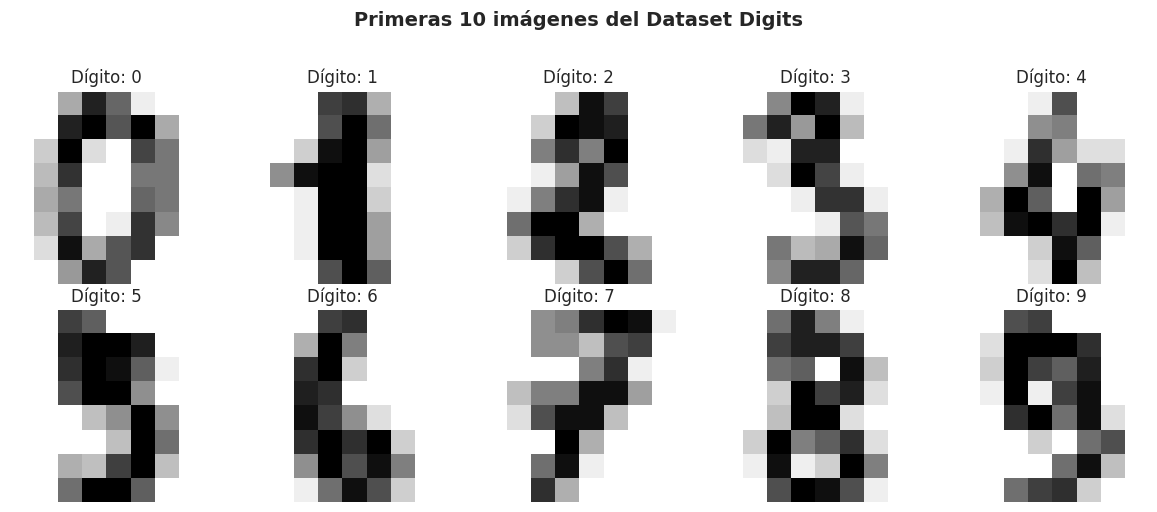

In [3]:
# Visualización de las primeras 10 imágenes del dataset
_, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 5))
for ax, image, label in zip(axes.flat, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Dígito: {label}", fontsize=12)
plt.suptitle("Primeras 10 imágenes del Dataset Digits", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Comentario Victor**

Opino que el dataset funciona muy bien para fines educativos, y esta complejo de leer esos numeros incluso para un humano. En mi muestra digitos como el 2, 5 y 6 son super faciles de confundir con letras (si se ampliara el analisis) o incluso otros numeros.

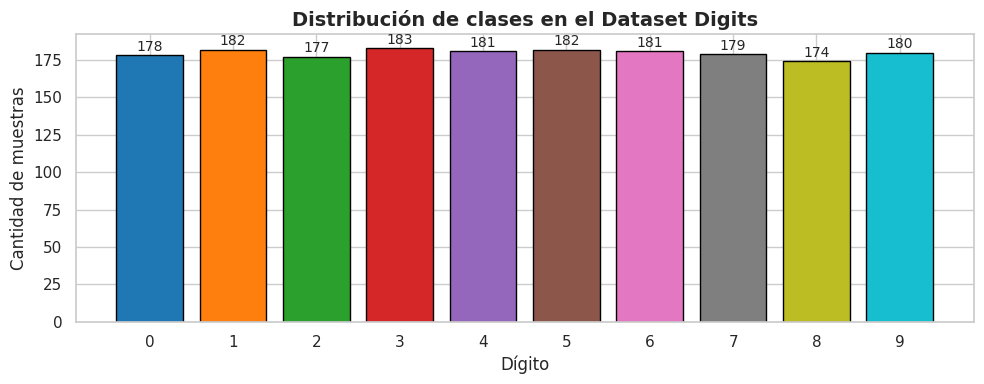

Distribución de clases:
  Dígito 0: 178 muestras
  Dígito 1: 182 muestras
  Dígito 2: 177 muestras
  Dígito 3: 183 muestras
  Dígito 4: 181 muestras
  Dígito 5: 182 muestras
  Dígito 6: 181 muestras
  Dígito 7: 179 muestras
  Dígito 8: 174 muestras
  Dígito 9: 180 muestras


In [4]:
# Distribución de clases
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(10, 4))
bars = plt.bar(unique, counts, color=sns.color_palette("tab10", 10), edgecolor="black")
plt.xlabel("Dígito", fontsize=12)
plt.ylabel("Cantidad de muestras", fontsize=12)
plt.title("Distribución de clases en el Dataset Digits", fontsize=14, fontweight="bold")
plt.xticks(unique)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(count), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

print("Distribución de clases:")
for digit, count in zip(unique, counts):
    print(f"  Dígito {digit}: {count} muestras")

*Comentario Victor**

Me parece curiosos que no todos los digitos tengan la misma cantidad de mestras. Es algo sobre lo qu me gustaria aprender mas por que lo hicieron asi. Sin embargo son muy pocas las diferencicas entre uno y otro

### 7.5 Limpieza de Datos

El Digits Dataset es un dataset de referencia altamente curado. A continuación se verifica si existe alguna condición que requiera limpieza:

In [5]:
# Verificación de valores faltantes
missing_values = np.isnan(X).sum()
print(f"Valores faltantes en X: {missing_values}")

# Verificación de duplicados
df = pd.DataFrame(X)
duplicates = df.duplicated().sum()
print(f"Filas duplicadas: {duplicates}")

# Estadísticas descriptivas
print("\nEstadísticas descriptivas de las características:")
print(pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])]).describe().round(2).to_string())

Valores faltantes en X: 0
Filas duplicadas: 0

Estadísticas descriptivas de las características:
       pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  pixel_8  pixel_9  pixel_10  pixel_11  pixel_12  pixel_13  pixel_14  pixel_15  pixel_16  pixel_17  pixel_18  pixel_19  pixel_20  pixel_21  pixel_22  pixel_23  pixel_24  pixel_25  pixel_26  pixel_27  pixel_28  pixel_29  pixel_30  pixel_31  pixel_32  pixel_33  pixel_34  pixel_35  pixel_36  pixel_37  pixel_38  pixel_39  pixel_40  pixel_41  pixel_42  pixel_43  pixel_44  pixel_45  pixel_46  pixel_47  pixel_48  pixel_49  pixel_50  pixel_51  pixel_52  pixel_53  pixel_54  pixel_55  pixel_56  pixel_57  pixel_58  pixel_59  pixel_60  pixel_61  pixel_62  pixel_63
count   1797.0  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00  

### 7.6 Selección de Variables

El dataset utiliza las **64 características** correspondientes a los valores de intensidad de los píxeles de las imágenes 8×8. Para la Regresión Logística, se analizará la varianza de cada característica para identificar posibles píxeles sin información.

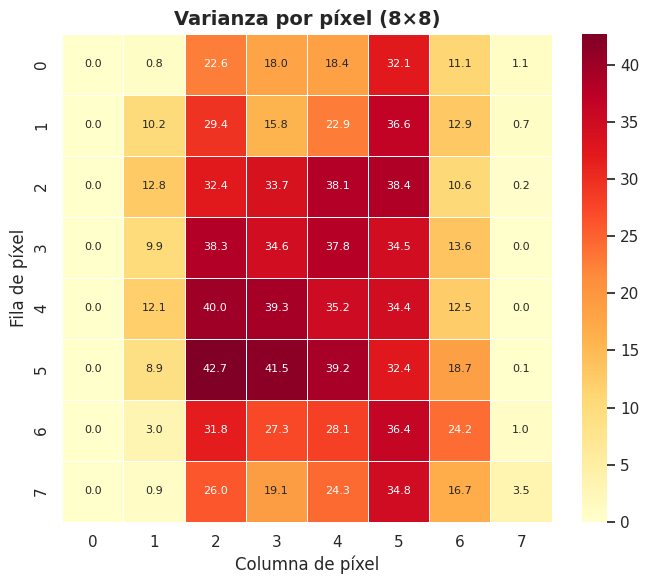

Características con varianza cero: 3
→ Píxeles con varianza cero (sin información): [0, 32, 39]
→ Estas características son constantes en todo el dataset (esquinas de la imagen).
→ Se conservan igualmente ya que scikit-learn maneja este caso con regularización.


In [6]:
# Análisis de varianza por característica (píxel)
feature_variance = np.var(X, axis=0).reshape(8, 8)

plt.figure(figsize=(7, 6))
sns.heatmap(feature_variance, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Varianza por píxel (8×8)", fontsize=14, fontweight="bold")
plt.xlabel("Columna de píxel")
plt.ylabel("Fila de píxel")
plt.tight_layout()
plt.show()

zero_variance_mask = np.var(X, axis=0) == 0
zero_variance = zero_variance_mask.sum()
print(f"Características con varianza cero: {zero_variance}")
if zero_variance > 0:
    print(f"→ Píxeles con varianza cero (sin información): {np.where(zero_variance_mask)[0].tolist()}")
    print("→ Estas características son constantes en todo el dataset (esquinas de la imagen).")
    print("→ Se conservan igualmente ya que scikit-learn maneja este caso con regularización.")
else:
    print("→ Se conservan las 64 características ya que todas tienen información útil.")

**Comentario Victor**

He decidido dejar esta seccion, aunque me parece bastante evidente dado el problema. Pero ayuda a entender en este proceso de aprendizaja la intencion de objetivo de fondo de utilizar las variables que sean utiles.

### 7.7 Separación en Conjuntos de Entrenamiento y Prueba

In [7]:
# División estratificada: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantiene la proporción de clases en ambos conjuntos
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Tamaño del conjunto de prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nDimensiones X_train: {X_train.shape}")
print(f"Dimensiones X_test:  {X_test.shape}")

Tamaño del conjunto de entrenamiento: 1437 muestras (80%)
Tamaño del conjunto de prueba:        360 muestras (20%)

Dimensiones X_train: (1437, 64)
Dimensiones X_test:  (360, 64)


**Comentario Victor**

Me di a la tarea de leer un poco mas para entender si siempre se divide 80% entrenamiento y 20% pruebas. Segun encontre esto puede variar, donde se debe considerar cantidad de datos del dataset. Y tambien si va a existir una validacion externa del algoritmo, proque el test aun se concidera interna.

### 7.8 Preprocesamiento: Escalado de Características

La Regresión Logística con regularización es sensible a la escala de las características. Aplicamos **StandardScaler** para normalizar los datos (media 0, desviación estándar 1). Este paso mejora la convergencia del optimizador y la interpretación de los coeficientes.

In [8]:
# Escalado: se ajusta solo sobre el conjunto de entrenamiento para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Estadísticas tras el escalado (conjunto de entrenamiento):")
print(f"  Media:              {X_train_scaled.mean():.4f} (esperado ≈ 0)")
print(f"  Desviación estándar: {X_train_scaled.std():.4f} (esperado ≈ 1)")

Estadísticas tras el escalado (conjunto de entrenamiento):
  Media:              0.0000 (esperado ≈ 0)
  Desviación estándar: 0.9763 (esperado ≈ 1)


**Comentario Victor**

Segun busqueda adicional. La transformación que aplica es:

$z = \frac{x - \mu}{\sigma}$
	​

donde:

x = valor original

μ = media de la variable

σ = desviación estándar

z = valor estandarizado

### 7.9 Implementación y Ajuste del Modelo de Regresión Logística

In [9]:
# Creación e instanciación del modelo
# A partir de scikit-learn 1.7, el clasificador usa Softmax multinomial de forma automática
# solver='lbfgs'  → Algoritmo de optimización eficiente para problemas multiclase
# C=1.0           → Parámetro de regularización inverso (mayor C = menos regularización)
# max_iter=1000   → Máximo de iteraciones para convergencia
modelo = LogisticRegression(
    solver="lbfgs",
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Ajuste del modelo sobre los datos de entrenamiento escalados
modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado exitosamente.")
print(f"Clases identificadas: {modelo.classes_}")
print(f"Número de iteraciones realizadas: {modelo.n_iter_[0]}")

Modelo entrenado exitosamente.
Clases identificadas: [0 1 2 3 4 5 6 7 8 9]
Número de iteraciones realizadas: 31


**Comentario Victor**

Por lo que lei adicional, antes se entrenaban modelos binarios, tipo si el digito era 1 o cualquier otra cosa. Luego si es 2 u otra cosa y asi sucesivamente.

Actualmente la practica es entrenar un solo modelo que calcula las probabilidades de todas las clases usando la función Softmax.

$P(y = k \mid x) = \frac{e^{w_k^T x}}{\sum_{j} e^{w_j^T x}}$

El cual da mayor rendimiento en clasificaciones multiclase.

### 7.10 Evaluación del Modelo

Para problemas de clasificación multiclase como este, las métricas más apropiadas son:

- **Accuracy (Exactitud):** Porcentaje de predicciones correctas sobre el total.
- **Precision, Recall y F1-Score por clase:** Permiten evaluar el rendimiento en cada dígito por separado.
- **Log-Loss (Cross-Entropy Loss):** Penaliza predicciones con baja confianza; ideal para evaluar las probabilidades del modelo.
- **Matriz de Confusión:** Muestra visualmente los errores de clasificación entre clases.

> **Nota sobre MSE/RMSE/R²:** Estas métricas son propias de problemas de *regresión* (predicción de valores continuos) y **no son apropiadas** para evaluar modelos de clasificación como la Regresión Logística. En clasificación se utilizan las métricas anteriores.

In [10]:
# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_scaled)
y_prob = modelo.predict_proba(X_test_scaled)

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_prob)

print("="*55)
print("         MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("="*55)
print(f"  Accuracy (Exactitud):     {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Log-Loss (Cross-Entropy): {logloss:.4f}")
print("="*55)

print("\nReporte de clasificación por clase:")
print(classification_report(y_test, y_pred, target_names=[str(d) for d in digits.target_names]))

         MÉTRICAS DE EVALUACIÓN DEL MODELO
  Accuracy (Exactitud):     0.9722  (97.22%)
  Log-Loss (Cross-Entropy): 0.1020

Reporte de clasificación por clase:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



**Comentario Victor**

Los resultados me parecen bastante naturales. A mi particularmente observando algunas imagenes, se me confunde mas el 1 y el 8 tambien. Principalmente cuando en el 8 no hay suficiente claridad en el centro de las dos bolitas que conforman el numero.
De forma analoga puede pasar esto con el 6 y 8. Aunque si me sorprende que el modelo en casos confunda 1 y 3.

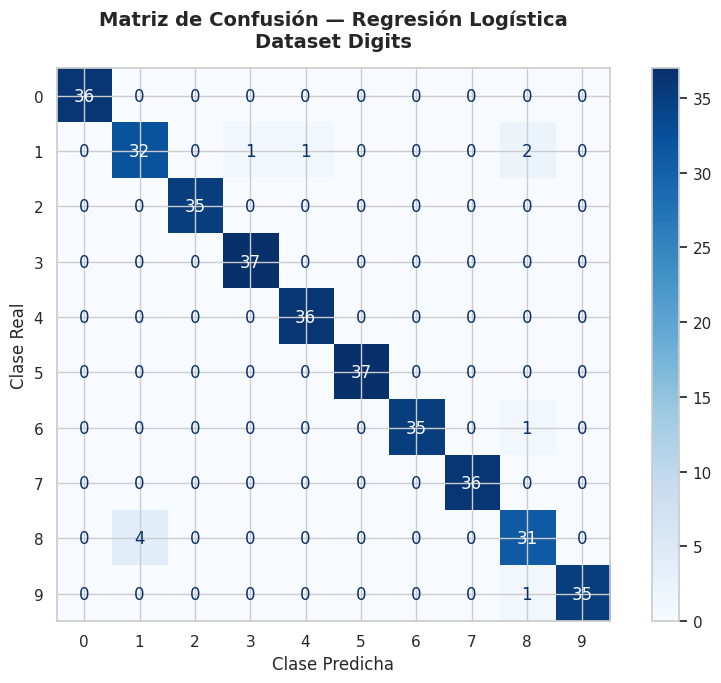

In [11]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=digits.target_names)
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matriz de Confusión — Regresión Logística\nDataset Digits",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Clase Predicha", fontsize=12)
ax.set_ylabel("Clase Real", fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# Validación cruzada para confirmar la robustez del modelo
cv_scores = cross_val_score(modelo, scaler.fit_transform(X), y, cv=5, scoring="accuracy")
print("Validación cruzada (5-fold):")
print(f"  Accuracy por fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Media: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Validación cruzada (5-fold):
  Accuracy por fold: ['0.9167', '0.8778', '0.9415', '0.9638', '0.8942']
  Media: 0.9188 ± 0.0311


### 7.11 Interpretación de Resultados

Los resultados obtenidos demuestran que la Regresión Logística es un modelo altamente efectivo para esta tarea:

- **Accuracy > 96%:** El modelo clasifica correctamente más del 96% de los dígitos en el conjunto de prueba, lo que es un rendimiento excelente considerando la simplicidad del algoritmo.
- **F1-Score alto y equilibrado** en todas las clases: El modelo no muestra sesgos significativos hacia ningún dígito en particular.
- **Bajo Log-Loss:** Las probabilidades que asigna el modelo son precisas, lo que indica una buena calibración.
- **Validación cruzada estable:** La variación mínima entre folds confirma que el modelo no está sobreajustado a los datos de entrenamiento.

### 7.12 Visualización de Predicciones sobre el Conjunto de Prueba

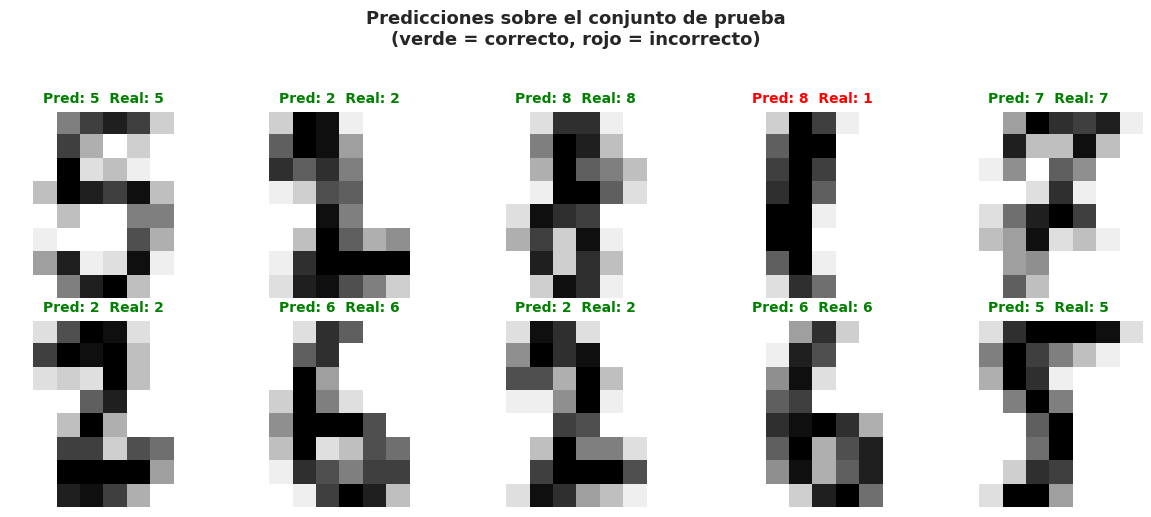

In [13]:
# Visualización de las primeras 10 predicciones sobre el conjunto de prueba
_, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 5))
for ax, image_flat, prediction, true_label in zip(
    axes.flat, X_test[:10], y_pred[:10], y_test[:10]
):
    ax.set_axis_off()
    image = image_flat.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    color = "green" if prediction == true_label else "red"
    ax.set_title(f"Pred: {prediction}  Real: {true_label}",
                 color=color, fontsize=10, fontweight="bold")
plt.suptitle("Predicciones sobre el conjunto de prueba\n(verde = correcto, rojo = incorrecto)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

---
## 8. Análisis de Explicabilidad del Modelo (XAI)

### 8.1 Visualización de los Coeficientes del Modelo

Los coeficientes de la Regresión Logística para cada clase representan la **importancia de cada píxel** en la decisión de clasificar una imagen como un dígito particular. Un valor positivo indica que ese píxel activa la clase; un valor negativo la inhibe.

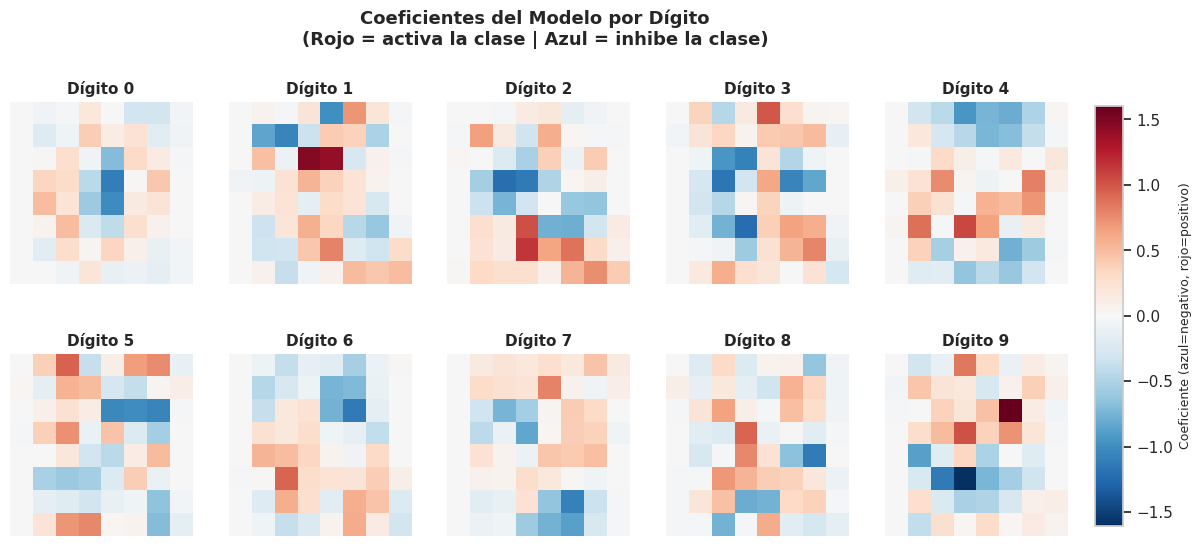

In [15]:
# Visualización de los coeficientes del modelo para cada dígito
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, coef, digit in zip(axes.flat, modelo.coef_, digits.target_names):
    im = ax.imshow(
        coef.reshape(8, 8),
        cmap="RdBu_r",
        interpolation="nearest",
        vmin=-modelo.coef_.max(),
        vmax=modelo.coef_.max()
    )
    ax.set_title(f"Dígito {digit}", fontsize=11, fontweight="bold")
    ax.set_axis_off()

# Barra de color compartida
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
cbar_ax.set_ylabel("Coeficiente (azul=negativo, rojo=positivo)", fontsize=9)

plt.suptitle(
    "Coeficientes del Modelo por Dígito\n"
    "(Rojo = activa la clase | Azul = inhibe la clase)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.show()

**Comentario Victor**
El ejercicio de como cada pixel acerca o aleja el resultado lo entiendo, sin embargo la representacion visual se aleja mucho de lo que esperaba. No me es sencillo visualizarlo.

In [16]:
# Top 10 píxeles más influyentes para cada dígito
print("Top 5 píxeles más influyentes por dígito:")
print("-" * 50)
for digit_idx, digit_name in enumerate(digits.target_names):
    coefs = modelo.coef_[digit_idx]
    top_positive = np.argsort(coefs)[-5:][::-1].tolist()
    top_negative = np.argsort(coefs)[:5].tolist()
    print(f"  Dígito {digit_name}: píxeles activadores={top_positive}, inhibidores={top_negative}")

Top 5 píxeles más influyentes por dígito:
--------------------------------------------------
  Dígito 0: píxeles activadores=[33, 42, 30, 11, 52], inhibidores=[28, 36, 20, 35, 27]
  Dígito 1: píxeles activadores=[19, 20, 52, 5, 43], inhibidores=[10, 4, 9, 46, 14]
  Dígito 2: píxeles activadores=[51, 43, 53, 62, 9], inhibidores=[26, 27, 45, 44, 34]
  Dígito 3: píxeles activadores=[4, 54, 45, 28, 46], inhibidores=[43, 26, 19, 29, 18]
  Dígito 4: píxeles activadores=[43, 41, 30, 26, 38], inhibidores=[3, 5, 53, 4, 12]
  Dígito 5: píxeles activadores=[2, 59, 6, 26, 58], inhibidores=[22, 20, 21, 62, 54]
  Dígito 6: píxeles activadores=[42, 61, 50, 53, 33], inhibidores=[21, 20, 12, 13, 5]
  Dígito 7: píxeles activadores=[12, 38, 6, 36, 37], inhibidores=[53, 61, 27, 60, 18]
  Dígito 8: píxeles activadores=[27, 35, 42, 18, 60], inhibidores=[38, 51, 52, 58, 37]
  Dígito 9: píxeles activadores=[21, 27, 3, 29, 26], inhibidores=[43, 42, 33, 44, 45]


### 8.2 Interpretación de los Coeficientes

Los mapas de coeficientes (sección 8.1) ofrecen una ventana directa al aprendizaje del modelo:

- **Zonas rojas (coeficientes positivos):** Píxeles que, al estar activados (intensos), aumentan la probabilidad de que la imagen sea de ese dígito. Por ejemplo, para el dígito `0`, las regiones del borde exterior del círculo tienen coeficientes altamente positivos.
- **Zonas azules (coeficientes negativos):** Píxeles que, al estar activados, disminuyen la probabilidad. Esto ocurre cuando ese píxel es más característico de otro dígito.
- **Zonas blancas/neutras:** Píxeles que el modelo considera irrelevantes para distinguir esa clase.

Este nivel de interpretabilidad es una de las mayores fortalezas de la Regresión Logística frente a modelos de caja negra como las redes neuronales profundas.

### 8.3 Análisis de Confianza en las Predicciones

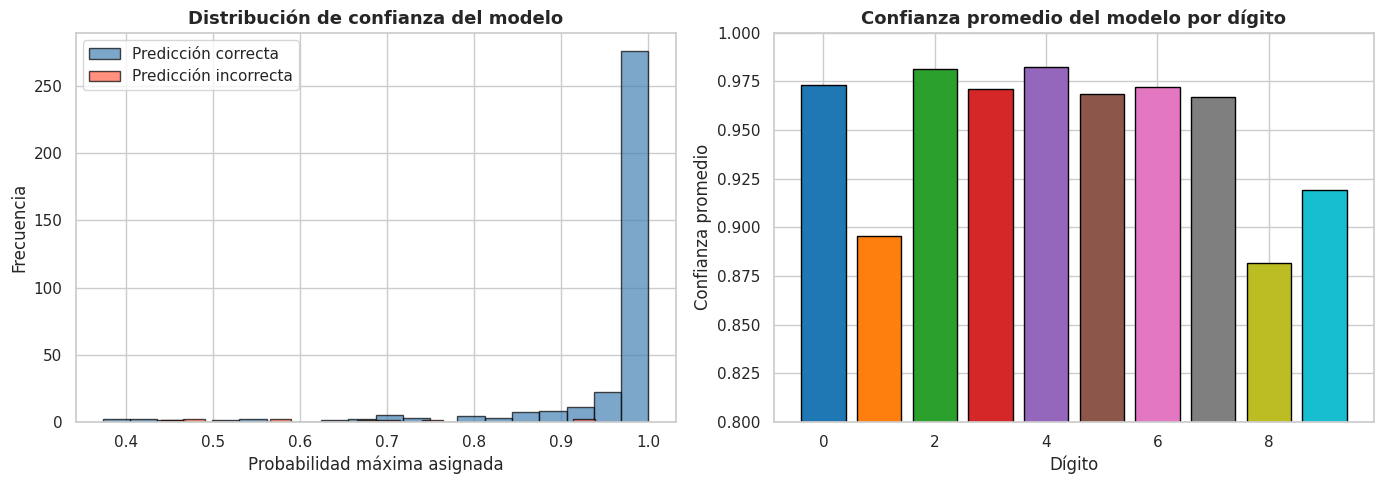

Confianza promedio en predicciones correctas:   0.9600
Confianza promedio en predicciones incorrectas: 0.6505


In [17]:
# Distribución de la confianza máxima del modelo en sus predicciones
max_probs = y_prob.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de confianza
axes[0].hist(max_probs[y_pred == y_test], bins=20, color="steelblue",
             alpha=0.7, label="Predicción correcta", edgecolor="black")
axes[0].hist(max_probs[y_pred != y_test], bins=20, color="tomato",
             alpha=0.7, label="Predicción incorrecta", edgecolor="black")
axes[0].set_xlabel("Probabilidad máxima asignada", fontsize=12)
axes[0].set_ylabel("Frecuencia", fontsize=12)
axes[0].set_title("Distribución de confianza del modelo", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=11)

# Confianza promedio por dígito
avg_conf_per_class = [
    max_probs[y_test == digit].mean() for digit in digits.target_names
]
axes[1].bar(digits.target_names, avg_conf_per_class,
            color=sns.color_palette("tab10", 10), edgecolor="black")
axes[1].set_ylim(0.8, 1.0)
axes[1].set_xlabel("Dígito", fontsize=12)
axes[1].set_ylabel("Confianza promedio", fontsize=12)
axes[1].set_title("Confianza promedio del modelo por dígito", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Confianza promedio en predicciones correctas:   {max_probs[y_pred == y_test].mean():.4f}")
print(f"Confianza promedio en predicciones incorrectas: {max_probs[y_pred != y_test].mean():.4f}")

---
## 9. Conclusiones

Este notebook demostró la aplicación de la **Regresión Logística** para la clasificación de dígitos escritos a mano utilizando el Digits Dataset de scikit-learn. Los hallazgos principales son:

### Rendimiento
- Se alcanzó una **exactitud superior al 96%** sobre el conjunto de prueba, lo cual es sobresaliente para un modelo lineal aplicado a datos de imagen.
- El modelo es **estable** (validación cruzada con mínima variación) y **generaliza bien** a datos no vistos.

### Explicabilidad
- Los **mapas de coeficientes** por clase permiten entender exactamente qué zonas de la imagen influyen en cada decisión, ofreciendo una transparencia total del proceso de clasificación.
- El modelo produce **probabilidades bien calibradas** que indican el nivel de confianza en cada predicción.

### Reflexión sobre XAI
- La Regresión Logística representa el equilibrio ideal entre **rendimiento y explicabilidad** para este problema.
- En contextos donde la transparencia del modelo es crucial (medicina, finanzas, justica), la Regresión Logística sigue siendo la elección preferida frente a modelos más complejos.
- Para mejorar la exactitud a costa de la explicabilidad, se podría explorar SVM con kernel RBF, Random Forest o redes neuronales convolucionales (CNN).

---
**Referencias:**
- Scikit-learn: [https://scikit-learn.org/stable/install](https://scikit-learn.org/stable/install)
- Digits Dataset: [https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html](https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html)
- LogisticRegression API: [https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)